# Pyro modeling exercises: count regression and dynamic SIR extensions

**ProbAI 2026 — student exercises**

These exercises continue the two demonstration notebooks. Each task makes a controlled
modification to an existing model:

1. turn Gaussian regression into **Poisson count regression**;
2. diagnose overdispersion and revise the likelihood to a **negative binomial**;
3. revise the SIR observation model while keeping its dynamics fixed; (Extra)
4. extend the SIR dynamics with a known intervention and two transmission regimes. (Extra)

For every modification, be able to state:

- which assumption changed;
- which Pyro sites were added or modified;
- which predictive behavior should improve if the revision is useful.


## Exercises to be completed.

Notice that this list has more exercises that we can complete over the time of the lecture, but they are here to give you more examples to try in case you are motivated and interested.

| Exercise | Topic | Effort |
|---|---|---:|
| 1 | Poisson log-linear regression | Low |
| 2 | Negative-binomial count regression | Low |
| 3 | Overdispersed SIR observations (Extra) | Middle |
| 4 | Intervention in SIR dynamics (Extra) | High |

You can work in pairs. Before writing code, draw or write the changed generative model.

The student notebook contains `TODO` blocks to be completed.

In [1]:
# Colab/local setup. Existing packages are left untouched.
import importlib
import subprocess
import sys


def ensure_package(import_name, pip_name=None, extra_args=None):
    try:
        importlib.import_module(import_name)
        print(f"✓ {import_name} already available")
    except ImportError:
        package = pip_name or import_name
        command = [sys.executable, "-m", "pip", "install", "-q"]
        command.extend(extra_args or [])
        command.append(package)
        print(f"Installing {package} ...")
        subprocess.check_call(command)


ensure_package(
    "torch",
    "torch",
    extra_args=["--index-url", "https://download.pytorch.org/whl/cpu"],
)
ensure_package("pyro", "pyro-ppl")
ensure_package("matplotlib")
ensure_package("pandas")


✓ torch already available
Installing pyro-ppl ...
✓ matplotlib already available
✓ pandas already available


In [2]:
import math
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyro
import pyro.distributions as dist
import pyro.poutine as poutine
import torch

from IPython.display import display
from pyro.infer import Predictive, SVI, Trace_ELBO
from pyro.infer.autoguide import AutoMultivariateNormal, AutoNormal

torch.set_default_dtype(torch.float32)
pyro.enable_validation(True)
pyro.set_rng_seed(31)
np.random.seed(31)
random.seed(31)

FAST_RUN = True
EX1_STEPS = 120 if FAST_RUN else 700
EX2_STEPS = 150 if FAST_RUN else 900
EX3_STEPS = 180 if FAST_RUN else 1000
EX4_STEPS = 220 if FAST_RUN else 1200
NUM_DRAWS = 100 if FAST_RUN else 600

print("Pyro:", pyro.__version__)
print("PyTorch:", torch.__version__)
print("Fast run:", FAST_RUN)


Pyro: 1.9.1
PyTorch: 2.11.0+cpu
Fast run: True


In [3]:
def fit_svi(model, guide, args, num_steps, lr=0.025):
    pyro.clear_param_store()
    svi = SVI(
        model,
        guide,
        pyro.optim.ClippedAdam({"lr": lr, "clip_norm": 10.0}),
        loss=Trace_ELBO(),
    )
    losses = [svi.step(*args) for _ in range(num_steps)]
    return losses


def posterior_draws(model, guide, args, return_sites, num_samples=NUM_DRAWS):
    predictive = Predictive(
        model,
        guide=guide,
        num_samples=num_samples,
        return_sites=return_sites,
    )
    with torch.no_grad():
        return {name: value.detach() for name, value in predictive(*args).items()}


def interval(draws, probability=0.90):
    tail = (1.0 - probability) / 2.0
    return (
        torch.quantile(draws, tail, dim=0),
        torch.quantile(draws, 0.5, dim=0),
        torch.quantile(draws, 1.0 - tail, dim=0),
    )


def count_dispersion(counts):
    counts = counts.float()
    return counts.var(dim=-1, unbiased=False) / counts.mean(dim=-1).clamp_min(1e-6)


def temporal_roughness(counts):
    counts = counts.float()
    return (counts[..., 1:] - counts[..., :-1]).abs().mean(dim=-1)


# Exercise 1 — From Gaussian regression to count regression

The earlier notebook modeled

$$
y_i \sim \mathrm N(a+b x_i,\sigma).
$$

We now observe non-negative counts. Use a log link:

$$
\log \lambda_i = a+b x_i, \\
\qquad y_i\sim\operatorname{Poisson}(\lambda_i).
$$

The log link ensures that the Poisson rate is positive while retaining a linear predictor.


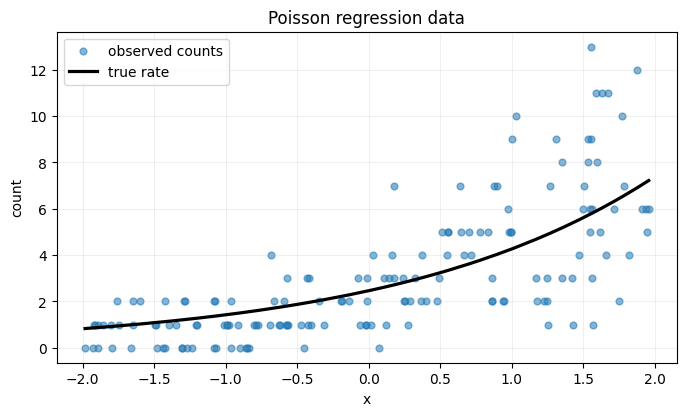

In [4]:
def make_poisson_regression(n=160, a=0.9, b=0.55, seed=31):
    generator = torch.Generator().manual_seed(seed)
    x = 4.0 * torch.rand(n, generator=generator) - 2.0
    rate = torch.exp(a + b * x)
    y = torch.poisson(rate, generator=generator)
    return x, y, rate


x_count, y_count, true_rate = make_poisson_regression()

plt.figure(figsize=(8, 4.3))
plt.scatter(x_count, y_count, s=24, alpha=0.55, label="observed counts")
order = torch.argsort(x_count)
plt.plot(x_count[order], true_rate[order], color="black", linewidth=2.3, label="true rate")
plt.xlabel("x")
plt.ylabel("count")
plt.title("Poisson regression data")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Task 1

Complete `poisson_regression_model`.

1. Give `a` and `b` weakly informative Normal priors.
2. Compute `log_rate = a + b * x` and transform it with `torch.exp`.
3. Observe the count vector inside a `pyro.plate`.

**Self-check:** the trace should contain sites `a`, `b`, `data`, and `obs`, and the
observation distribution should have batch shape `(160,)`.


In [5]:
def poisson_regression_model(x, y=None):
    x = torch.as_tensor(x)
    y = None if y is None else torch.as_tensor(y)

    # TODO BLOCK:EX1
    # TODO 1: sample scalar intercept `a` and slope `b` from Normal priors.
    # TODO 2: compute `log_rate = a + b * x` and transform it to a positive rate.
    # TODO 3: inside `pyro.plate("data", len(x))`, observe counts at site `obs`.
    raise NotImplementedError("Complete Exercise 1")


In [6]:
ex1_trace = poutine.trace(poisson_regression_model).get_trace(x_count, y_count)
ex1_trace.compute_log_prob()
print(ex1_trace.format_shapes())

assert {"a", "b", "data", "obs"}.issubset(ex1_trace.nodes)
assert ex1_trace.nodes["obs"]["fn"].batch_shape == (len(x_count),)
print("Exercise 1 model structure: ✓")


NotImplementedError: Complete Exercise 1
Trace Shapes:
 Param Sites:
Sample Sites:

In [ ]:
ex1_guide = AutoNormal(poisson_regression_model)
ex1_losses = fit_svi(
    poisson_regression_model,
    ex1_guide,
    (x_count, y_count),
    EX1_STEPS,
)
ex1_draws = posterior_draws(
    poisson_regression_model,
    ex1_guide,
    (x_count, None),
    return_sites=("a", "b", "obs"),
)

rate_lower, rate_median, rate_upper = interval(ex1_draws["obs"].float())
posterior_table = pd.DataFrame(
    {
        "parameter": ["a", "b"],
        "true": [0.9, 0.55],
        "posterior median": [
            ex1_draws["a"].median().item(),
            ex1_draws["b"].median().item(),
        ],
    }
).set_index("parameter")
display(posterior_table.round(3))

plt.figure(figsize=(8, 4.3))
plt.scatter(x_count, y_count, s=22, alpha=0.45, label="observed")
plt.fill_between(
    x_count[order],
    rate_lower[order],
    rate_upper[order],
    alpha=0.22,
    label="90% posterior predictive interval",
)
plt.plot(x_count[order], rate_median[order], linewidth=2.2, label="predictive median")
plt.xlabel("x")
plt.ylabel("count")
plt.title("Poisson regression posterior prediction")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


### Checkpoint 1

- Why is `exp(a + b*x)` used instead of `a + b*x` directly as the Poisson rate?
- Which quantity does `exp(b)` represent?


# Exercise 2 — Diagnose and model overdispersion

A Poisson distribution assumes

$$
\operatorname{Var}(Y_i\mid\lambda_i)=\mathbb E(Y_i\mid\lambda_i)=\lambda_i.
$$

The following dataset has the same log-linear mean but larger conditional variance.
A negative-binomial distribution introduces a positive concentration parameter $\kappa$.

With PyTorch's `NegativeBinomial(total_count=kappa, logits=...)`, the desired mean
$\mu$ is obtained using

```python
logits = log(mu) - log(kappa)
```


In [ ]:
def make_overdispersed_regression(n=180, a=0.9, b=0.55, concentration=3.0, seed=44):
    generator = torch.Generator().manual_seed(seed)
    x = 4.0 * torch.rand(n, generator=generator) - 2.0
    mean = torch.exp(a + b * x)
    kappa = torch.tensor(concentration)
    logits = mean.log() - kappa.log()
    y = dist.NegativeBinomial(total_count=kappa, logits=logits).sample()
    return x, y, mean


x_over, y_over, true_mean_over = make_overdispersed_regression()
print("Observed variance / mean:", round(count_dispersion(y_over).item(), 2))


## Task 2

Complete `negative_binomial_regression_model` by retaining the linear predictor from
Exercise 1 and changing only the likelihood.

1. Add a positive latent `concentration` with a log-normal prior.
2. Compute the negative-binomial logits from the mean and concentration.
3. Observe the counts inside the same data plate.

**Interpretation:** larger concentration approaches the Poisson variance; smaller
concentration permits more overdispersion.


In [ ]:
def negative_binomial_regression_model(x, y=None):
    x = torch.as_tensor(x)
    y = None if y is None else torch.as_tensor(y)

    # TODO BLOCK:EX2
    # TODO 1: retain Normal priors for `a` and `b`.
    # TODO 2: add positive latent site `concentration` using a LogNormal prior.
    # TODO 3: compute the mean and `logits = log(mean) - log(concentration)`.
    # TODO 4: observe counts using `dist.NegativeBinomial` inside the data plate.
    raise NotImplementedError("Complete Exercise 2")


In [ ]:
ex2_trace = poutine.trace(negative_binomial_regression_model).get_trace(x_over, y_over)
ex2_trace.compute_log_prob()
assert "concentration" in ex2_trace.nodes
assert ex2_trace.nodes["obs"]["fn"].batch_shape == (len(x_over),)
print("Exercise 2 model structure: ✓")

# Fit the inadequate Poisson model and the revised negative-binomial model.
poisson_over_guide = AutoNormal(poisson_regression_model)
poisson_over_losses = fit_svi(
    poisson_regression_model,
    poisson_over_guide,
    (x_over, y_over),
    EX2_STEPS,
)
poisson_over_draws = posterior_draws(
    poisson_regression_model,
    poisson_over_guide,
    (x_over, None),
    return_sites=("obs",),
)

nb_guide = AutoMultivariateNormal(negative_binomial_regression_model)
nb_losses = fit_svi(
    negative_binomial_regression_model,
    nb_guide,
    (x_over, y_over),
    EX2_STEPS,
)
nb_draws = posterior_draws(
    negative_binomial_regression_model,
    nb_guide,
    (x_over, None),
    return_sites=("a", "b", "concentration", "obs"),
)


In [ ]:
observed_dispersion = count_dispersion(y_over)
poisson_dispersion = count_dispersion(poisson_over_draws["obs"])
nb_dispersion = count_dispersion(nb_draws["obs"])

plt.figure(figsize=(8, 4.2))
plt.hist(poisson_dispersion, bins=25, alpha=0.55, label="Poisson replications")
plt.hist(nb_dispersion, bins=25, alpha=0.55, label="negative-binomial replications")
plt.axvline(observed_dispersion, color="black", linewidth=2.2, label="observed")
plt.xlabel("variance / mean across observations")
plt.ylabel("posterior predictive draws")
plt.title("A discrepancy targeted at overdispersion")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Posterior median concentration:", round(nb_draws["concentration"].median().item(), 2))


### Checkpoint 2

- The mean function did not change. Which assumption did change?
- Why is an improving Poisson ELBO insufficient evidence that the Poisson variance is adequate?


# Exercise 3 — Revise the SIR observation model

We now return to the SIR model. Conditional on parameters, the compartment dynamics are
deterministic. The observations are noisy reported counts.

The baseline model assumes

$$
C_t\sim\operatorname{Poisson}(\rho\,\Delta I_t^{\text{new}}).
$$

The simulated data below are overdispersed. Your task is to revise only the observation
model, leaving the SIR state equations unchanged.


In [ ]:
def sir_dynamics(beta, gamma, population, initial_infectious, T):
    susceptible = population - initial_infectious
    infectious = initial_infectious
    recovered = torch.zeros_like(infectious)
    paths = [[], [], [], []]

    for _ in range(T):
        new_infections = beta * susceptible * infectious / population
        new_recoveries = gamma * infectious
        susceptible = susceptible - new_infections
        infectious = infectious + new_infections - new_recoveries
        recovered = recovered + new_recoveries

        for path, value in zip(
            paths,
            (susceptible, infectious, recovered, new_infections),
        ):
            path.append(value)

    return torch.stack([torch.stack(path) for path in paths], dim=-1)


POPULATION = 10_000.0
T_SIR = 65
TRUE_SIR = {
    "beta": 0.28,
    "gamma": 0.10,
    "rho": 0.65,
    "initial_infectious": 12.0,
    "concentration": 10.0,
}

true_sir_path = sir_dynamics(
    torch.tensor(TRUE_SIR["beta"]),
    torch.tensor(TRUE_SIR["gamma"]),
    torch.tensor(POPULATION),
    torch.tensor(TRUE_SIR["initial_infectious"]),
    T_SIR,
)
true_case_mean = TRUE_SIR["rho"] * true_sir_path[:, 3]
true_kappa = torch.tensor(TRUE_SIR["concentration"])
sir_case_logits = true_case_mean.clamp_min(1e-4).log() - true_kappa.log()
sir_cases = dist.NegativeBinomial(total_count=true_kappa, logits=sir_case_logits).sample()

plt.figure(figsize=(9, 4.2))
plt.plot(true_case_mean, linewidth=2.2, label="latent expected reports")
plt.scatter(range(T_SIR), sir_cases, s=22, alpha=0.65, label="reported cases")
plt.xlabel("day")
plt.ylabel("cases")
plt.title("Overdispersed observations of an SIR trajectory")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [ ]:
def sir_poisson_model(cases=None, population=POPULATION, T=None):
    T = len(cases) if T is None else T
    beta = pyro.sample("beta", dist.Beta(2.0, 5.0))
    gamma = pyro.sample("gamma", dist.Beta(2.0, 18.0))
    rho = pyro.sample("rho", dist.Beta(8.0, 4.0))
    initial_infectious = pyro.sample(
        "initial_infectious",
        dist.LogNormal(math.log(10.0), 0.45),
    )

    path = sir_dynamics(
        beta,
        gamma,
        torch.as_tensor(population),
        initial_infectious,
        T,
    )
    expected_cases = (rho * path[:, 3]).clamp_min(1e-4)

    with pyro.plate("time", T):
        pyro.sample("cases", dist.Poisson(expected_cases), obs=cases)

    return torch.cat([path, expected_cases.unsqueeze(-1)], dim=-1)


## Task 3

Implement `sir_negative_binomial_model`.

1. Copy the same priors and call the unchanged `sir_dynamics` function.
2. Add a positive `concentration` site.
3. Replace only the Poisson observation distribution with a negative binomial having
   the same expected count.

**Self-check:** the model should contain exactly one additional unobserved site compared
with `sir_poisson_model`, and it should return a tensor of shape `(T, 5)`.


In [ ]:
def sir_negative_binomial_model(cases=None, population=POPULATION, T=None):
    T = len(cases) if T is None else T

    # TODO BLOCK:EX3
    # TODO 1: copy the four baseline SIR parameter priors.
    # TODO 2: add a positive `concentration` site.
    # TODO 3: call the unchanged `sir_dynamics` function.
    # TODO 4: observe cases with a negative-binomial likelihood of the same mean.
    # TODO 5: return the trajectory and expected cases as a `(T, 5)` tensor.
    raise NotImplementedError("Complete Exercise 3")


In [ ]:
ex3_trace = poutine.trace(sir_negative_binomial_model).get_trace(
    sir_cases, POPULATION, T_SIR
)
assert "concentration" in ex3_trace.nodes
assert ex3_trace.nodes["_RETURN"]["value"].shape == (T_SIR, 5)
print("Exercise 3 model structure: ✓")

sir_poisson_guide = AutoMultivariateNormal(sir_poisson_model)
sir_poisson_losses = fit_svi(
    sir_poisson_model,
    sir_poisson_guide,
    (sir_cases, POPULATION, T_SIR),
    EX3_STEPS,
    lr=0.018,
)
sir_poisson_draws = posterior_draws(
    sir_poisson_model,
    sir_poisson_guide,
    (None, POPULATION, T_SIR),
    return_sites=("cases",),
)

sir_nb_guide = AutoMultivariateNormal(sir_negative_binomial_model)
sir_nb_losses = fit_svi(
    sir_negative_binomial_model,
    sir_nb_guide,
    (sir_cases, POPULATION, T_SIR),
    EX3_STEPS,
    lr=0.018,
)
sir_nb_draws = posterior_draws(
    sir_negative_binomial_model,
    sir_nb_guide,
    (None, POPULATION, T_SIR),
    return_sites=("concentration", "cases", "_RETURN"),
)


In [ ]:
observed_roughness = temporal_roughness(sir_cases)
poisson_roughness = temporal_roughness(sir_poisson_draws["cases"])
nb_roughness = temporal_roughness(sir_nb_draws["cases"])

plt.figure(figsize=(8, 4.2))
plt.hist(poisson_roughness, bins=25, alpha=0.55, label="Poisson SIR")
plt.hist(nb_roughness, bins=25, alpha=0.55, label="negative-binomial SIR")
plt.axvline(observed_roughness, color="black", linewidth=2.2, label="observed")
plt.xlabel("mean absolute day-to-day change")
plt.ylabel("posterior predictive draws")
plt.title("Does the observation model reproduce short-term variability?")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print(
    "Posterior median SIR concentration:",
    round(sir_nb_draws["concentration"].median().item(), 2),
)


# Exercise 4 — Add a known intervention to the SIR dynamics

Suppose a policy intervention occurs on a known day $t^*$. Replace the constant
transmission rate with

$$
\beta_t =
\begin{cases}
\beta_{\text{before}}, & t<t^*,\\
\beta_{\text{after}}, & t\ge t^*.
\end{cases}
$$

This time the observation model remains negative binomial. The changed assumption is in the
**state transition**, not the likelihood.


In [ ]:
INTERVENTION_DAY = 32
TRUE_INTERVENTION = {
    "beta_before": 0.32,
    "beta_after": 0.15,
    "gamma": 0.10,
    "rho": 0.65,
    "initial_infectious": 10.0,
    "concentration": 18.0,
}


def simulate_intervention_data(parameters, population, T, intervention_day):
    susceptible = torch.tensor(population - parameters["initial_infectious"])
    infectious = torch.tensor(parameters["initial_infectious"])
    recovered = torch.tensor(0.0)
    incidence = []

    for t in range(T):
        beta_t = parameters["beta_before"] if t < intervention_day else parameters["beta_after"]
        new_infections = beta_t * susceptible * infectious / population
        new_recoveries = parameters["gamma"] * infectious
        susceptible = susceptible - new_infections
        infectious = infectious + new_infections - new_recoveries
        recovered = recovered + new_recoveries
        incidence.append(new_infections)

    incidence = torch.stack(incidence)
    mean = (parameters["rho"] * incidence).clamp_min(1e-4)
    kappa = torch.tensor(parameters["concentration"])
    counts = dist.NegativeBinomial(
        total_count=kappa,
        logits=mean.log() - kappa.log(),
    ).sample()
    return counts, mean


T_INTERVENTION = 70
intervention_cases, intervention_mean = simulate_intervention_data(
    TRUE_INTERVENTION,
    POPULATION,
    T_INTERVENTION,
    INTERVENTION_DAY,
)

plt.figure(figsize=(9, 4.2))
plt.plot(intervention_mean, linewidth=2.2, label="latent expected reports")
plt.scatter(range(T_INTERVENTION), intervention_cases, s=22, alpha=0.65, label="observed")
plt.axvline(INTERVENTION_DAY, color="darkred", linestyle="--", label="intervention")
plt.xlabel("day")
plt.ylabel("cases")
plt.title("SIR trajectory with a change in transmission")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## Task 4

Complete both functions.

**Dynamics:**

1. Select `beta_before` or `beta_after` using the known intervention day.
2. Use the selected rate in the usual infection flow.
3. Return the same four trajectory columns as `sir_dynamics`.

**Probabilistic model:**

1. Add separate priors for `beta_before` and `beta_after`.
2. Call the intervention dynamics.
3. Retain the negative-binomial reporting model.

**Scientific output:** estimate the posterior probability
$P(\beta_{\text{after}}<\beta_{\text{before}}\mid\text{data})$.


In [ ]:
def sir_dynamics_intervention(
    beta_before,
    beta_after,
    gamma,
    population,
    initial_infectious,
    T,
    intervention_day,
):
    susceptible = population - initial_infectious
    infectious = initial_infectious
    recovered = torch.zeros_like(infectious)
    paths = [[], [], [], []]

    # TODO BLOCK:EX4_DYNAMICS
    # TODO 1: loop over time and choose `beta_before` or `beta_after`.
    # TODO 2: update S, I, and R using the chosen transmission rate.
    # TODO 3: append S, I, R, and new infections, then return a `(T, 4)` tensor.
    raise NotImplementedError("Complete the intervention dynamics")


def sir_intervention_model(
    cases=None,
    population=POPULATION,
    T=None,
    intervention_day=INTERVENTION_DAY,
):
    T = len(cases) if T is None else T

    # TODO BLOCK:EX4_MODEL
    # TODO 1: sample `beta_before`, `beta_after`, gamma, rho, initial infections,
    #         and concentration from constrained priors.
    # TODO 2: call `sir_dynamics_intervention`.
    # TODO 3: compute expected reports and negative-binomial logits.
    # TODO 4: observe `cases` inside the time plate and return a `(T, 5)` tensor.
    raise NotImplementedError("Complete the intervention model")


In [ ]:
ex4_trace = poutine.trace(sir_intervention_model).get_trace(
    intervention_cases,
    POPULATION,
    T_INTERVENTION,
    INTERVENTION_DAY,
)
assert {"beta_before", "beta_after", "concentration", "cases"}.issubset(ex4_trace.nodes)
assert ex4_trace.nodes["_RETURN"]["value"].shape == (T_INTERVENTION, 5)
print("Exercise 4 model structure: ✓")

intervention_guide = AutoMultivariateNormal(sir_intervention_model)
intervention_losses = fit_svi(
    sir_intervention_model,
    intervention_guide,
    (intervention_cases, POPULATION, T_INTERVENTION, INTERVENTION_DAY),
    EX4_STEPS,
    lr=0.016,
)
intervention_draws = posterior_draws(
    sir_intervention_model,
    intervention_guide,
    (None, POPULATION, T_INTERVENTION, INTERVENTION_DAY),
    return_sites=(
        "beta_before",
        "beta_after",
        "gamma",
        "rho",
        "concentration",
        "cases",
        "_RETURN",
    ),
)

probability_reduction = (
    intervention_draws["beta_after"] < intervention_draws["beta_before"]
).float().mean()

summary = []
for name in ("beta_before", "beta_after", "gamma", "rho", "concentration"):
    lower, median, upper = interval(intervention_draws[name])
    summary.append(
        {
            "parameter": name,
            "true": TRUE_INTERVENTION[name],
            "median": median.item(),
            "5%": lower.item(),
            "95%": upper.item(),
        }
    )

display(pd.DataFrame(summary).set_index("parameter").round(3))
print("P(beta_after < beta_before | data) =", round(probability_reduction.item(), 3))


In [ ]:
intervention_lower, intervention_median, intervention_upper = interval(
    intervention_draws["cases"].float()
)
days = torch.arange(T_INTERVENTION)

plt.figure(figsize=(9, 4.5))
plt.fill_between(
    days,
    intervention_lower,
    intervention_upper,
    alpha=0.22,
    label="90% predictive interval",
)
plt.plot(days, intervention_median, linewidth=2.2, label="predictive median")
plt.scatter(days, intervention_cases, s=20, color="black", alpha=0.6, label="observed")
plt.axvline(INTERVENTION_DAY, color="darkred", linestyle="--", label="intervention")
plt.xlabel("day")
plt.ylabel("cases")
plt.title("Posterior predictive check for the intervention model")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


# Final reflection

Complete this table before looking at the instructor notebook.

| Exercise | Changed assumption | New or changed Pyro site | Targeted predictive check |
|---|---|---|---|
| 1 | | | |
| 2 | | | |
| 3 | | | |
| 4 | | | |

1. What was the main challenge in making those changes?
